# Anti-Bunching Copilot — Experiment Notebook

**COMPX523-26A Assignment 3 · SUNT (Salvador) · driver-facing streaming ML**

This notebook runs the experiment behind `Proposals/01-anti-bunching-copilot.md` end-to-end on the **SUNT OD** data. It is narrated section-by-section and calls the same functions in `src/` that the CLI scripts (`prepare_data.py` → `run_experiment.py` → `make_figures.py`) use, so the **notebook, scripts, and report figures stay consistent**.

## What the experiment tests
> **Can a streaming model predict bunching early enough, reliably enough, and on the rare positive class — and does an adaptive model actually beat simpler approaches?** If it can't, the in-cab nudge has nothing trustworthy to say.

Each section below is framed by the question it answers (matching §5 of the proposal).

## Before you run
- Use the project venv (Python 3.12): `experiments/anti-bunching-copilot/.venv`. Launch Jupyter from it, or select it as the kernel.
- **Java 11+** must be available (CapyMOA runs on a JVM). The setup cell resolves `JAVA_HOME` on macOS automatically.
- Scope (routes / dates / thresholds) lives in `config.yaml`. It defaults to a **small scope (2 routes, 1 day)** so the notebook runs in a couple of minutes. Widen it there for the full study.

## 1. Setup
Resolve `JAVA_HOME` (CapyMOA/JVM), load `config.yaml`, and fix the random seed. Everything downstream reads its scope and hyperparameters from the config object, so the run is fully reproducible.

In [1]:
import numpy as np, pandas as pd
from src.config import load_config, ensure_java_home

jh = ensure_java_home()
print('JAVA_HOME =', jh)

cfg = load_config()
np.random.seed(cfg.seed)
print('OD dir   :', cfg.od_dir)
print('scope    :', cfg.scope['routes'], cfg.scope['directions'], cfg.scope['start_date'], '..', cfg.scope['end_date'])
print('label    :', cfg.label)
print('model    :', cfg.model)

JAVA_HOME = /Library/Java/JavaVirtualMachines/temurin-24.jdk/Contents/Home
OD dir   : /Users/ademartutor/Documents/UoW/Trimester A - 2026/COMPX523 - Machine Learning for Data Streams/Assignment 3/Dataset/SUNT/data/od
scope    : ['1007', '1386', '1346', '1649'] ['I', 'V'] 2024-03-01 .. 2024-03-03
label    : {'bunch_frac': 0.4, 'warn_frac': 0.6, 'horizon_stops': 3, 'horizon_minutes': 10, 'headway_window': 8}
model    : {'arf_ensemble_size': 25, 'grace_period': 200, 'adwin_delta': 0.002, 'windowed_eval_size': 1000, 'random_seed': 42}


## 2. Load & scope the OD data — *"can we even see bunching in this data?"*

The provided 10-stop, 5-/30-min aggregate **cannot** support this project: aggregating events into per-stop time buckets destroys the gap between two specific successive buses, which is exactly what bunching is. So we use the **raw per-event OD parquet** (the brief explicitly encourages additional public SUNT data), scoped to a few busy routes to stay tractable.

Each OD row is *one bus arriving at one stop* with a timestamp (`stop_time`) and crowding (`loading`). Note the boarding/alighting columns are **hyphenated**: `n-boardings`, `n-alighting`.

In [2]:
from src.headway import load_od
s = cfg.scope
od_raw = load_od(cfg.od_dir, s['routes'], s['directions'], s['start_date'], s['end_date'])
print('rows:', len(od_raw), '| vehicles:', od_raw.vehicle.nunique(), '| trips:', od_raw.trip_id.nunique())
od_raw[['vehicle','route_short_name','direction_id','trip_id','pt_sequence','stop_id','stop_time','n-boardings','loading']].head()

  [load] od-2024-03-01.parquet: 47,006 scoped rows


  [load] od-2024-03-02.parquet: 28,531 scoped rows
  [load] od-2024-03-03.parquet: 25,109 scoped rows
rows: 100646 | vehicles: 257 | trips: 1317


,vehicle,route_short_name,direction_id,trip_id,pt_sequence,stop_id,stop_time,n-boardings,loading
0,20431,1386,I,20431_1386_1,1,45834097,2024-03-01 05:48:06,2.157993,2.157993
1,20431,1386,I,20431_1386_1,2,44782442,2024-03-01 05:48:20,4.315987,6.473979
2,20431,1386,I,20431_1386_1,3,47566681,2024-03-01 05:49:30,0.000000,6.473979
3,20431,1386,I,20431_1386_1,4,44783270,2024-03-01 05:50:09,0.000000,6.473979
4,20431,1386,I,20431_1386_1,5,47568385,2024-03-01 05:50:33,0.000000,6.473979


## 3. Reconstruct trajectories & forward headway

This step **creates the prediction problem** — without it there is no label and no features. For each trip we order stops by `pt_sequence`/`stop_time`; for each (route, direction, stop) we compute the **forward headway** = minutes since the *previous distinct vehicle* arrived. We also derive segment travel time, a dwell proxy, and a rolling *local normal* headway per stop.

We drop the ~2–3% of trips with non-monotonic `stop_time`. The printed headway spread should show the real signal (tight gaps when bunched ↔ long gaps in service).

In [3]:
from src.headway import drop_nonmonotonic_trips, add_segment_and_dwell, add_forward_headway
od = od_raw.copy()
if cfg.preprocess.get('drop_nonmonotonic', True):
    od, frac = drop_nonmonotonic_trips(od)
    print(f'dropped {frac:.1%} of trips for non-monotonic stop_time')
od = add_segment_and_dwell(od)
od = add_forward_headway(od, int(cfg.preprocess['min_headway_seconds']), int(cfg.label['headway_window']))
print(od['headway_min'].describe()[['min','25%','50%','75%','max']])

dropped 25.4% of trips for non-monotonic stop_time
min      0.500000
25%      8.800000
50%     20.033333
75%     34.933333
max    824.616667
Name: headway_min, dtype: float64


## 4. Build the label & features — *"predict bunching* before *it happens"*

**Label (target only, never a feature):** look `horizon_stops` ahead on the same trip and take the minimum forward headway; if that future gap drops below `bunch_frac` × local-normal it's **bunching (2)**, below `warn_frac` it's **warning (1)**, else **ok (0)**. The label uses data *after* `t`; the features use only data `≤ t`. This causal split is what keeps the experiment honest and makes it about **lead time**, not after-the-fact detection.

The printed class balance shows the **imbalance** that makes recall/F1 on the bunching class (not accuracy) the metric that matters.

In [4]:
from src.features import make_dataset, FEATURE_COLS, LABELS
ds = make_dataset(od, cfg)
print('instances:', len(ds))
print('features :', FEATURE_COLS)
bal = ds['label'].value_counts().sort_index()
print('class balance:', {LABELS[k]: int(v) for k, v in bal.items()})
ds.head()

instances: 55759
features : ['headway_min', 'headway_ratio', 'headway_trend', 'since_prev_stop_min', 'loading', 'recent_boardings', 'pt_sequence', 'minute_of_day', 'dow', 'is_peak']
class balance: {'ok': 38449, 'warning': 5342, 'bunching': 11968}


,route_short_name,direction_id,vehicle,trip_id,stop_id,stop_time,local_median_headway,headway_min,headway_ratio,headway_trend,since_prev_stop_min,loading,recent_boardings,pt_sequence,minute_of_day,dow,is_peak,label
0,1346,I,20194,20194_1346_1,44042532,2024-03-01 04:57:35,13.683333,8.183333,0.598051,-11.350000,0.000000,12.570538,12.570538,1,297,4,0,1
1,1346,I,20194,20194_1346_1,44782893,2024-03-01 04:57:50,13.733333,8.083333,0.588592,-11.250000,0.250000,12.570538,12.570538,2,297,4,0,1
2,1346,I,20194,20194_1346_1,45834753,2024-03-01 04:58:33,13.816667,7.983333,0.577805,-11.500000,0.716667,12.570538,12.570538,3,298,4,0,1
3,1346,I,20194,20194_1346_1,44783344,2024-03-01 04:58:48,13.850000,7.933333,0.572804,-11.166667,0.250000,13.618083,1.047545,4,298,4,0,1
4,1346,I,20194,20194_1346_1,45833160,2024-03-01 04:59:51,14.000000,8.083333,0.577381,-11.233333,1.050000,18.855806,6.285269,5,299,4,0,1


*(Optional)* Persist the processed dataset so the CLI `run_experiment.py` can reuse it and so the result is reproducible from a file.

In [5]:
cfg.processed_path.parent.mkdir(parents=True, exist_ok=True)
ds.to_csv(cfg.processed_path, index=False)
print('wrote', cfg.processed_path)

wrote /Users/ademartutor/Documents/UoW/Trimester A - 2026/COMPX523 - Machine Learning for Data Streams/Assignment 3/experiments/anti-bunching-copilot/data/processed/features.csv


## 5. Baselines — *"is the ML actually earning its keep?"*

This is the heart of the experiment. If the streaming models can't beat a **static threshold** ("is the gap small *right now*?") or **previous-headway persistence**, the premise that you need adaptive streaming ML collapses. All baselines are scored on the **same chronological frame** as the models.

In [6]:
from src import baselines as B
from src.experiment import classification_metrics
lab = cfg.label
y = ds['label'].to_numpy()
base = {
    'static_threshold': classification_metrics(y, B.static_threshold(ds, lab['bunch_frac'], lab['warn_frac'])),
    'previous_headway': classification_metrics(y, B.previous_headway_persistence(ds, lab['bunch_frac'], lab['warn_frac'])),
}
pd.DataFrame(base).T[['recall_bunching','f1_bunching','balanced_accuracy','kappa']]

,recall_bunching,f1_bunching,balanced_accuracy,kappa
static_threshold,0.894469,0.911801,0.903616,0.882937
previous_headway,0.176805,0.180231,0.344984,-0.013102


## 6. Streaming models, prequentially — *"prove it works the way it'd be deployed"*

We run **Hoeffding Adaptive Tree** (built-in ADWIN) and **Adaptive Random Forest** with strict **test-then-train** in chronological order: for each bus arrival the model predicts, we record it, then the model learns the true outcome. No random split — that would leak the future. A standalone ADWIN over the error stream logs drift points.

This cell calls the exact same `run_prequential` the CLI uses; it saves `predictions.csv`, `metrics.json`, `nudges.json`, `drift_events.json` to `outputs/`.

In [7]:
from src.experiment import run_prequential, build_metrics_table, save_outputs
res = run_prequential(ds, cfg)
pred_frame = res['predictions']
metrics = build_metrics_table(pred_frame, cfg)
save_outputs(pred_frame, res, metrics, cfg)
pred_frame.head()

  [save] outputs -> /Users/ademartutor/Documents/UoW/Trimester A - 2026/COMPX523 - Machine Learning for Data Streams/Assignment 3/experiments/anti-bunching-copilot/outputs


,stop_time,trip_id,route_short_name,direction_id,stop_id,pt_sequence,headway_min,label,local_median_headway,pred_HAT,pred_ARF
0,2024-03-01 04:57:35,20194_1346_1,1346,I,44042532,1,8.183333,1,13.683333,0,0
1,2024-03-01 04:57:50,20194_1346_1,1346,I,44782893,2,8.083333,1,13.733333,0,0
2,2024-03-01 04:58:33,20194_1346_1,1346,I,45834753,3,7.983333,1,13.816667,1,1
3,2024-03-01 04:58:48,20194_1346_1,1346,I,44783344,4,7.933333,1,13.850000,1,1
4,2024-03-01 04:59:51,20194_1346_1,1346,I,45833160,5,8.083333,1,14.000000,1,1


## 7. Metrics — *"what success concretely means"*

Two things must **both** hold for the nudge to be worth showing a driver:
- **Recall on the bunching class** — does it catch the real events? (a miss is the costly error)
- **Nudge lead time** — does it warn *early enough to act*? (minutes before observed bunching)

Reported alongside: precision / F1 / balanced accuracy / κ, and stream cost (drift points). This table mirrors **Table 1 in §6** of the proposal — replace the proposal's `TBD`s with these numbers.

In [8]:
rows = []
for name, m in metrics.items():
    lead = m.get('nudge_lead', {}).get('median_lead_min')
    rows.append({'model': name, 'balanced_acc': round(m['balanced_accuracy'], 3),
                 'recall_bunching': round(m['recall_bunching'], 3),
                 'f1_bunching': round(m['f1_bunching'], 3),
                 'kappa': round(m['kappa'], 3),
                 'median_lead_min': (round(lead, 1) if lead is not None else None)})
pd.DataFrame(rows).set_index('model')

,balanced_acc,recall_bunching,f1_bunching,kappa,median_lead_min
model,,,,,
static_threshold,0.904,0.894,0.912,0.883,NaN
previous_headway,0.345,0.177,0.180,-0.013,NaN
HAT,0.881,0.902,0.904,0.863,26.3
ARF,0.915,0.916,0.918,0.891,26.5


## 7b. Model bake-off — *which CapyMOA model fits best, empirically*

Rather than infer the model from the EDA, we run several CapyMOA classifiers **prequentially on the same stream** and rank them by bunching-class F1. All run test-then-train in chronological order on identical data, so the comparison is fair. Candidates span a non-learning floor (`MajorityClass`), a simple Bayes/lazy learner (`NaiveBayes`, `KNN`), single trees (`HoeffdingTree`, `EFDT`), the adaptive tree (`HAT`), and the adaptive ensemble (`ARF`); the non-learning `static_threshold` baseline is shown for reference.

Throughput (`instances_per_sec`) matters too: the copilot must run online in-cab, so a model that is far more accurate but far slower is a real trade-off.

In [9]:
from src.experiment import bake_off
bake = bake_off(ds, cfg)   # uses the same `ds` and config as the main run
bake.round(3)

,model,f1_bunching,recall_bunching,precision_bunching,balanced_accuracy,kappa,sec,instances_per_sec
0,ARF,0.918,0.916,0.919,0.915,0.891,8.8,6320.0
1,static_threshold (baseline),0.912,0.894,0.930,0.904,0.883,0.0,NaN
2,HAT,0.904,0.902,0.907,0.881,0.863,1.0,57907.0
3,HoeffdingTree,0.898,0.891,0.905,0.860,0.854,0.7,74782.0
4,EFDT,0.875,0.833,0.922,0.759,0.761,0.9,62850.0
5,KNN,0.814,0.798,0.831,0.795,0.749,5.3,10614.0
6,MajorityClass,0.000,0.000,0.000,0.335,0.002,0.7,77979.0
7,NaiveBayes,0.000,0.000,0.000,0.333,0.000,0.6,90110.0


## 8. Figures

All figures are regenerated from the saved `outputs/`, so the report and the demo app show exactly the same thing:
- **String diagram** — vehicles' arrivals along the route; converging lines = bunching, with predicted nudges (orange) and observed bunching (red ×).
- **Rolling accuracy** — prequential accuracy over time, HAT vs ARF, with ADWIN drift markers.
- **Lead-time histogram** — distribution of how early the nudge fires.

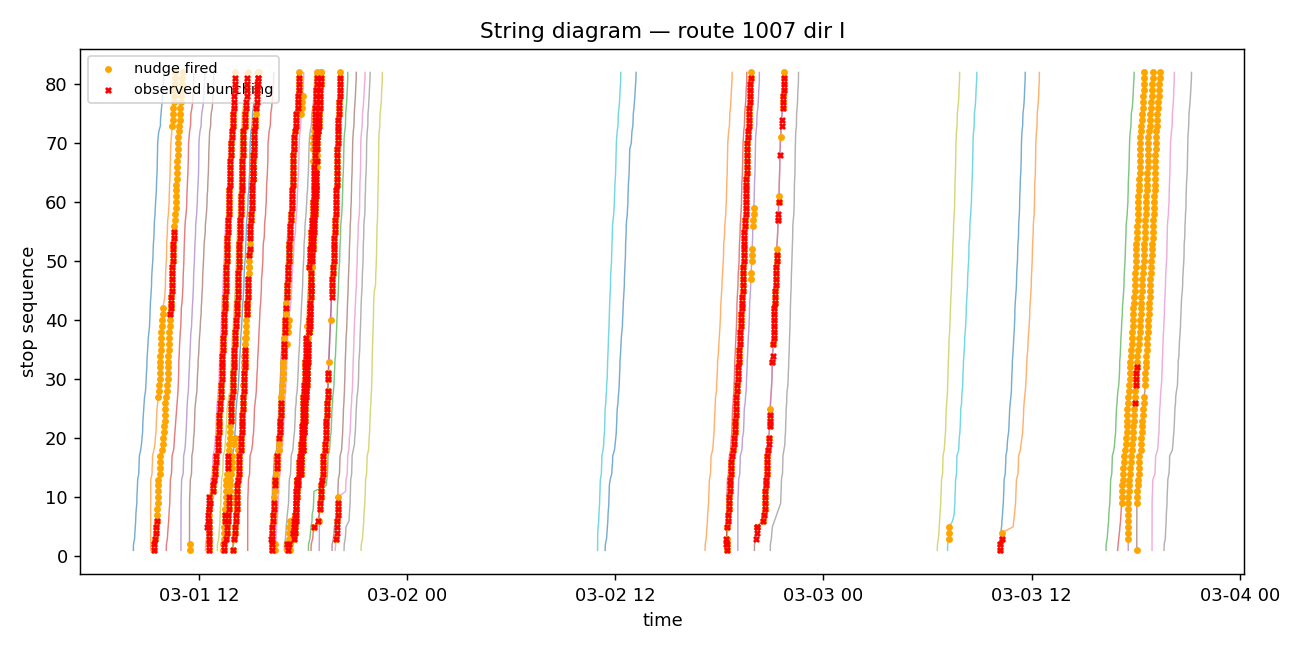

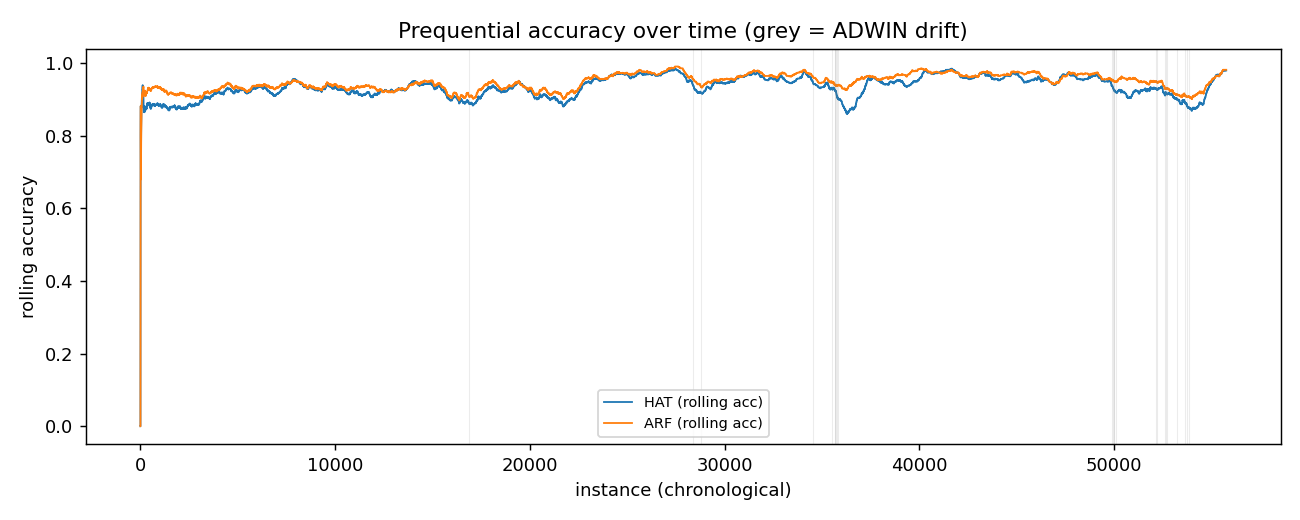

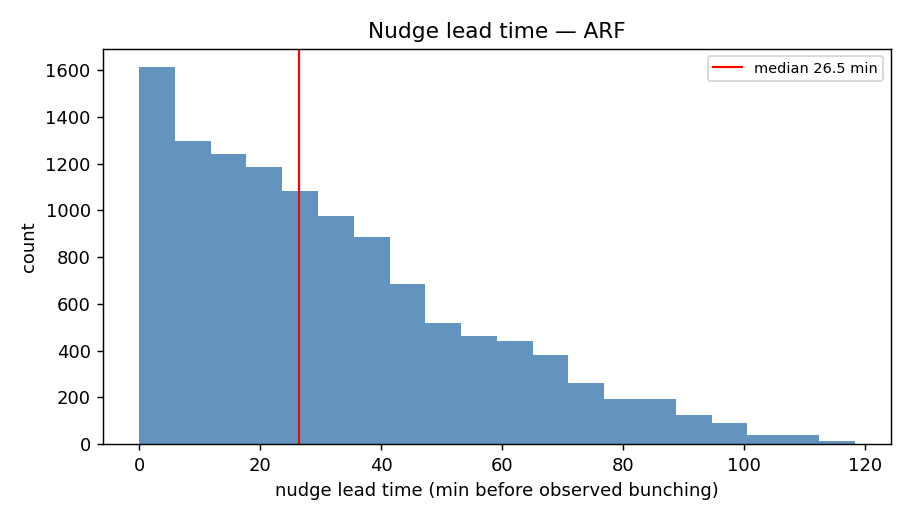

In [10]:
from src.plots import fig_string_diagram, fig_rolling_accuracy, fig_lead_time_hist
from IPython.display import Image, display
figs = cfg.figures_dir; figs.mkdir(parents=True, exist_ok=True)
r, d = cfg.scope['routes'][0], cfg.scope['directions'][0]
p_str = fig_string_diagram(pred_frame, r, d, figs)
p_acc = fig_rolling_accuracy(res, figs)
p_lead = fig_lead_time_hist(metrics, figs, model='ARF')
for p in [p_str, p_acc, p_lead]:
    if p: display(Image(filename=str(p)))

## 9. *(Optional)* Illustrative simulation — not a measured outcome

A light "if flagged drivers had eased, would headway variance fall?" check. This is **simulation only**: the historical data cannot show how headways would have changed under different driver behaviour (see §7 Limitations of the proposal). Treat any number here as illustrative, not evidence of real-world impact.

In [11]:
# Illustrative only: compare headway-ratio variance on stops the model flagged vs not.
pf = pred_frame.copy()
ratio = (pf['headway_min'] / pf['local_median_headway']).replace([np.inf, -np.inf], np.nan)
flagged = pf['pred_ARF'] >= 1
print('headway-ratio variance  | flagged stops:', round(ratio[flagged].var(), 3),
      '| unflagged:', round(ratio[~flagged].var(), 3))
print('(Illustrative: a real easing effect cannot be observed from historical data.)')

headway-ratio variance  | flagged stops: 0.04 | unflagged: 9.605
(Illustrative: a real easing effect cannot be observed from historical data.)


## 10. Conclusions & next steps

- Paste the §7 metrics table into **Table 1 (§6)** of `01-anti-bunching-copilot.md`, replacing the `TBD`s.
- **Widen scope** in `config.yaml` (more routes / more days) for the full study; tune `bunch_frac`, `horizon_stops`, and the ARF `ensemble_size`.
- The saved `outputs/` (`predictions.csv`, `metrics.json`, `nudges.json`, `drift_events.json`) are exactly what the **FastAPI + Next.js in-cab demo** consumes — no recomputation needed for the presentation-safe mode.
- **Honesty checks:** chronological order (no leakage) · imbalance-aware metrics · the easing effect is simulated, not measured · results are for the scoped routes, not all of Salvador.